In [17]:
# ensures that if we change something in .core, it sees it imediately without having to restart the kernel
# every time you run a cell, all imported modules are reloaded auomatically
%load_ext autoreload
%autoreload 2 

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [18]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.cm as cm
from matplotlib.colors import LinearSegmentedColormap
import scipy
from kneed import KneeLocator
from statsmodels.tsa.stattools import adfuller
import pandas as pd

# Our package
import neuro_lib as nl

# SETTING SEED FOR REPRODUCIBILITY
np.random.seed(0)

relations_dict = {"linear": lambda s: s,
                "tanh": lambda s: np.tanh(5*s),
                "quadratic": lambda s: 2 * s**2 - 1}

# Data with temporal structure
In the previous section, we evaluated different Mutual Information estimators (KDE, binning, Gaussian, and Gaussian Copula) on i.i.d. variables with known functional dependencies (linear, quadratic, and non-linear transformations). This allowed us to assess their ability to capture static dependencies under controlled conditions.

We now extend the analysis to the temporal domain, where dependencies are directional and evolve over time. In this context, Transfer Entropy (TE) provides a natural generalization of MI, enabling the detection of directed information flow between time series.

## Transfer Entropy
Transfer Entropy ($TE$) is a directional measure of information transfer. It quantifies how much the uncertainty of the future of a target signal $Y$ is reduced by knowing the past of a source signal $X$, beyond what is already explained by the past of $Y$ itself. Formally, for a source $X$ and target $Y$ with a coupling lag $\ell$ and embedding dimension $m$:$$TE_{X \to Y}(\ell) = I(Y_t ; X_{t-\ell} \mid Y^{(m)}_{t-1})$$Using the chain rule of information, this Conditional Mutual Information can be decomposed into the difference of two Shannon Entropies:$$TE_{X \to Y}(\ell) = H(Y_t \mid Y^{(m)}_{t-1}) - H(Y_t \mid Y^{(m)}_{t-1}, X_{t-\ell})$$

#### Relationship with MI Estimators
One of the core strengths of our neuro_lib is its modularity. We do not implement new mathematical engines for Transfer Entropy; instead, we reuse our Mutual Information (MI) Estimators by reformulating TE as a sum of MI terms.For any stationary process, TE can be expressed as:$$TE_{X \to Y}(\ell) = I(X_{t-\ell} ; [Y_t, Y^{(m)}_{t-1}]) - I(X_{t-\ell} ; Y^{(m)}_{t-1})$$ This allows us to leverage the four estimators already implemented in estimators.py. 

#### Directedness Index ($DI$)
To distinguish between true causality and simple correlation, we compute the Directedness Index:$$DI = TE_{X \to Y} - TE_{Y \to X}$$ 

- $DI > 0$: Information flows predominantly from $X$ to $Y$.
- $DI \approx 0$: The relationship is either non-existent or purely symmetric (correlation).

To systematically evaluate the performance of TE estimators, we generate synthetic time series with known ground-truth causal structure. This allows us to benchmark the estimators under controlled settings before applying them to real neural data.


### Simulated time series

Linear System: Autoregressive (AR) Processes

We generate coupled autoregressive processes to model linear interactions with a known directional structure. A typical formulation is:

\begin{aligned}
X_t &= \alpha X_{t-1} + \epsilon_t^X \\
Y_t &= \beta Y_{t-1} + \gamma X_{t-\ell} + \epsilon_t^Y
\end{aligned}

where:
*	$\alpha, \beta$ control the persistence of each process,
*	$\gamma$ determines the coupling strength from X to Y,
*	$\ell$ is the true interaction lag,
*	$\epsilon_t^X, \epsilon_t^Y$ are Gaussian noise terms.

This setup defines a clear ground-truth direction of information flow ($X \rightarrow Y$), making it ideal for validating whether TE correctly identifies both direction and lag.


Simulated data provides full access to the ground-truth generative mechanism, including the direction of information flow (X → Y), the interaction lag (ℓ), and the coupling strength, all defined a priori during data generation.

This enables a systematic validation of Transfer Entropy estimators by assessing whether they correctly recover:
*	the direction of information transfer,
*	the true interaction lag,
*	and the sensitivity of estimates with respect to known reference values.

The goal is not to obtain an exact analytical value of Transfer Entropy (which is generally intractable in nonlinear systems), but to evaluate the consistency of different estimators with the known causal structure.

The simulation framework also allows controlled stress testing by varying:
*	Signal-to-Noise Ratio (SNR), to assess robustness to noise,
*	sample size (N), to analyze finite-sample bias and variance,
*	coupling strength, to evaluate sensitivity to interaction intensity.

This controlled setting enables a reproducible and systematic comparison of estimation methods under progressively more challenging conditions.

In [19]:
# Generate artificial time series
N = 5000
(x,y) = nl.generate_ar_coupled(N, lag=5)

### Pre-analysis and Parameter Selection

Before computing Transfer Entropy, standard preprocessing steps are applied:
*	Stationarity check (ADF test): verifies that the time series has stable statistical properties over time, a requirement for reliable inference.

Augmented Dickey-Fuller (ADF) Test. To ensure the stability of our information measures, we test for stationarity. The ADF test checks for a unit root in the signal by fitting the following regression:$$\Delta y_t = \alpha + \delta y_{t-1} + \sum_{i=1}^{p} \beta_i \Delta y_{t-i} + \epsilon_t$$Null Hypothesis ($H_0$): $\delta = 0$ (The process has a unit root and is non-stationary). Success Criterion: A $p$-value $< 0.05$ allows us to reject $H_0$, confirming the signal is stationary and suitable for TE analysis.

*	Embedding delay (τ, first minimum of MI): identifies the time lag that best reduces redundancy between embedded components.

Average Mutual Information (AMI)To determine the optimal embedding delay ($\tau$), we calculate the Mutual Information between a signal and its lagged version across a range of delays.$$I(Y_t ; Y_{t-\tau}) = \sum_{y_t, y_{t-\tau}} P(y_t, y_{t-\tau}) \log_2 \frac{P(y_t, y_{t-\tau})}{P(y_t)P(y_{t-\tau})}$$ Selection Criterion: We select $\tau$ at the first local minimum of the AMI curve. This ensures that the components of our embedded vector are sufficiently independent, maximizing the information content of the reconstructed state space.

*	Embedding dimension (m, FNN method): determines the minimum state-space dimension needed to unfold the underlying dynamics without self-overlaps.

To find the minimum embedding dimension ($m$), we analyze how the proximity of points changes as we increase the dimensionality of the phase space.Let $R_m^2(t)$ be the distance between a point and its nearest neighbor in $m$ dimensions. After moving to $m+1$ dimensions, the new distance is $R_{m+1}^2(t)$. A neighbor is declared false if:$$\sqrt{\frac{R_{m+1}^2(t) - R_m^2(t)}{R_m^2(t)}} > R_{tol}$$Selection Criterion: We choose the smallest $m$ such that the percentage of False Nearest Neighbors drops below a predefined threshold (typically $1\%$). This indicates that the attractor is fully "unfolded" and self-intersections are resolved.

These steps ensure that the reconstructed state space is appropriate for TE estimation and comparable across methods.


Checking AR:
  [OK] Source (X) is stationary (p-value: 0.0000e+00)
  > Source (X) Optimal Delay: 6
  > Target (Y) Optimal Delay: 9
  [Note] Large discrepancy in Tau between X and Y. Consider using separate embeddings.


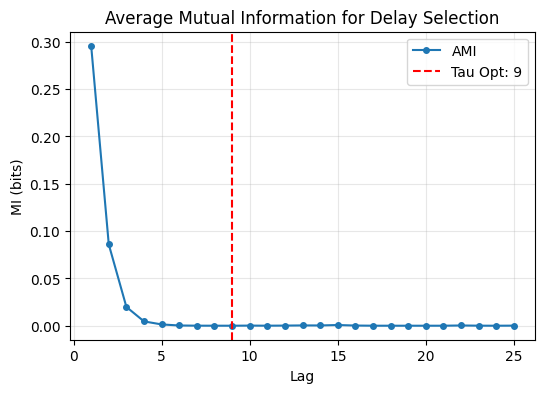


Results for AR:
  > Optimal m: 4


/Users/angelabortolato/Desktop/ITI_GroupProject/neuro_lib/diagnostics.py:80: RuntimeWarning: divide by zero encountered in divide
  is_fnn = (r_m1 / r_m > R_tol)


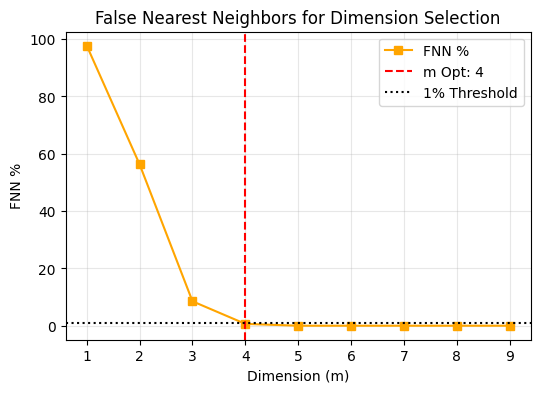

  [OK] Target (Y) is stationary (p-value: 0.0000e+00)
  > Source (X) Optimal Delay: 6
  > Target (Y) Optimal Delay: 9
  [Note] Large discrepancy in Tau between X and Y. Consider using separate embeddings.


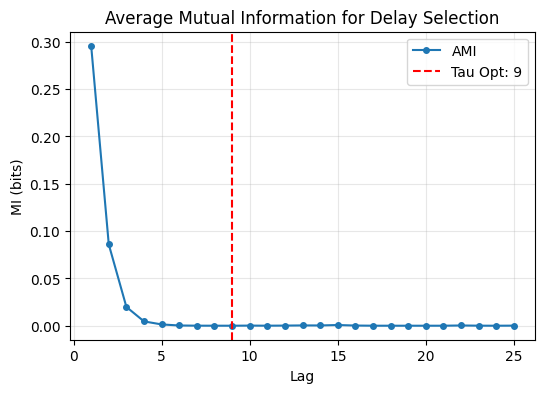

/Users/angelabortolato/Desktop/ITI_GroupProject/neuro_lib/diagnostics.py:80: RuntimeWarning: divide by zero encountered in divide
  is_fnn = (r_m1 / r_m > R_tol)



Results for AR:
  > Optimal m: 4


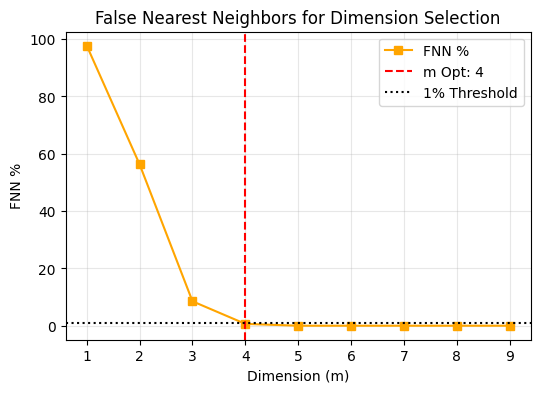

In [20]:
# We will store the results to use them later in the TE calculation
optimal_params = {}


print(f"\nChecking AR:")
    # Test Stationarity with ADF
    # Test both Source (X) and Target (Y)
for label, signal in [("Source (X)", x), ("Target (Y)", y)]:
    is_stationary, p_val = nl.check_stationarity(signal)
        
    if is_stationary:
        print(f"  [OK] {label} is stationary (p-value: {p_val:.4e})")
    else:
        # Throw a warning if p-value >= 0.05
        print(f"  [WARNING] {label} is NOT stationary (p-value: {p_val:.4e})")

    # Find embedding delay = the optimal spacing between embedded components such that there is no redundancy
    # Analyze Source (X), here use gc because faster
    tau_x, lags_x, mi_x = nl.find_optimal_delay(x,max_lag=25, method='gc')
    
    # Analyze Target (Y)
    tau_y, lags_y, mi_y = nl.find_optimal_delay(y,max_lag=25, method='gc')
    
    # Store results
    optimal_params = {'tau_x': tau_x, 'tau_y': tau_y}
    
    print(f"  > Source (X) Optimal Delay: {tau_x}")
    print(f"  > Target (Y) Optimal Delay: {tau_y}")
    
    # Check for discrepancy
    if abs(tau_x - tau_y) > 2:
        print(f"  [Note] Large discrepancy in Tau between X and Y. Consider using separate embeddings.")
    else:
        print(f"  [Note] Taus are similar. A unified embedding (Tau={tau_y}) is likely sufficient.")

    nl.plot_diagnostic_ami(lags_y, mi_y, tau_y)

    # Find embedding dimension m
    # Run FNN on Target (Y)
    m_opt, m_range, fnn_vals = nl.find_optimal_dimension(y, tau=optimal_params["tau_y"])
    
    print(f"\nResults for AR:")
    print(f"  > Optimal m: {m_opt}")
    
    # Plotting the result
    nl.plot_diagnostic_fnn(m_range, fnn_vals, m_opt)

    optimal_params = {
        'tau': tau_y,
        'm': m_opt,
    }




    well i obtain a larger m than expected for AR, this may be due to a high noise wrt signal

### Estimator Benchmarking (Lag Scanning)

In this phase, we perform a Lag Sweep to evaluate how accurately different TE estimators identify the pre-defined interaction delay. We use high SNR ($N=5000$, low noise) to establish an "ideal" baseline. We look for "consensus", so that different methods find same lag.

By construction we know the ground truth: Lag = 5

### Implementation Goals
1. Generate a "Latency Profile" for each method.
2. Identify which method is most robust to the non-linearities of the Oscillator model.
3. Compare the "sharpness" of the information peak across methods.

To ensure the estimators are not just detecting "shared information" (correlation) but truly "directional flow" (causality), we perform a symmetry test. 

We compare:
1. **True Direction ($X \rightarrow Y$):** Expect a significant peak at the ground-truth lag.
2. **Reverse Direction ($Y \rightarrow X$):** Expect values close to the noise floor, as $Y$ does not drive $X$ in our generative models.

**Success Criterion:** The Directedness Index ($DI = TE_{forward} - TE_{backward}$) should be significantly positive at the true lag.

Lag scanning AR


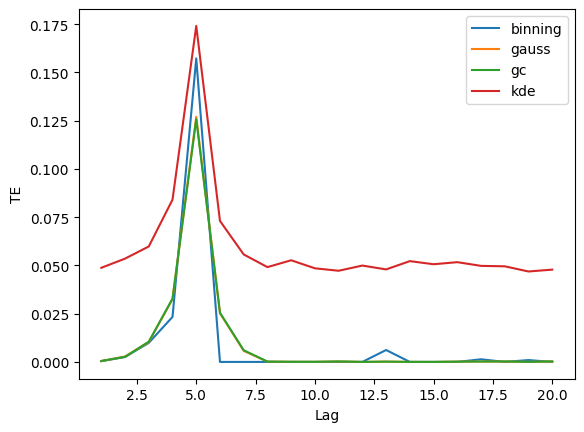

In [22]:
lags = range(1, 21)
methods = ['binning', 'gauss', 'gc', 'kde']
bins_to_test = np.arange(5, 30)

print("Lag scanning AR")
for mth in methods:
        m = optimal_params['m']
        m=1
        tau = optimal_params['tau']

        if mth == 'binning':
            te_profile = [nl.transfer_entropy_withMI(x, y, method=mth, lag=l, m=m, tau=tau, bins=bins_to_test) for l in lags]
        else:
            te_profile = [nl.transfer_entropy_withMI(x, y, method=mth, lag=l, m=m, tau=tau) for l in lags]
             
        plt.plot(lags, te_profile, label=mth)
        plt.xlabel("Lag")
        plt.ylabel("TE")
plt.legend()
plt.show()


For the AR model all methods correctly identify lag=5. kde (red) is broader and has a higher "baseline." This is because KDE is a "smoothing" estimator; it often overestimates information (positive bias) in small samples.


Running Symmetry Test for AR


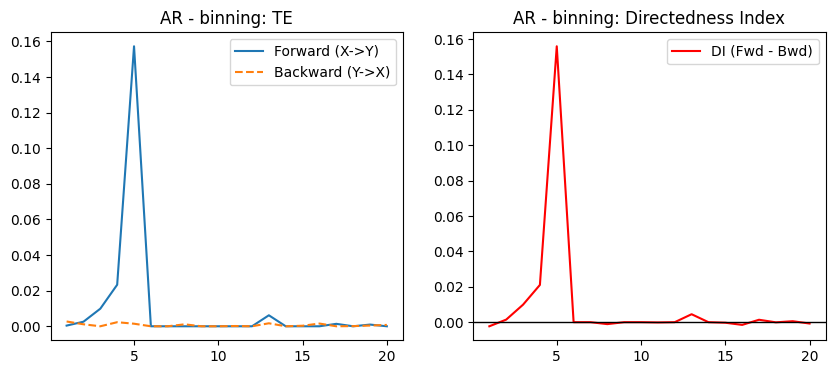

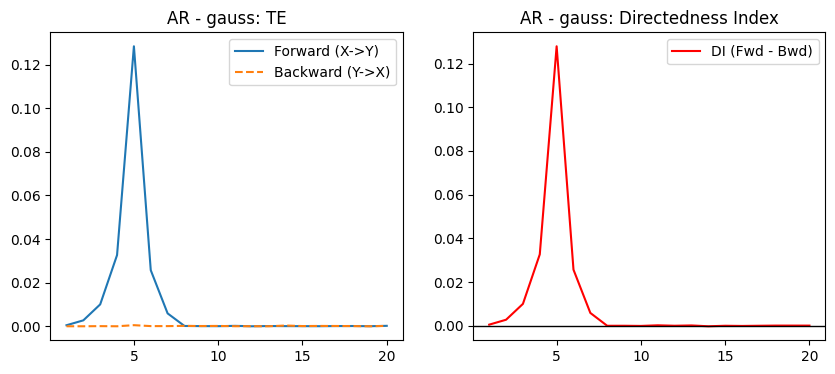

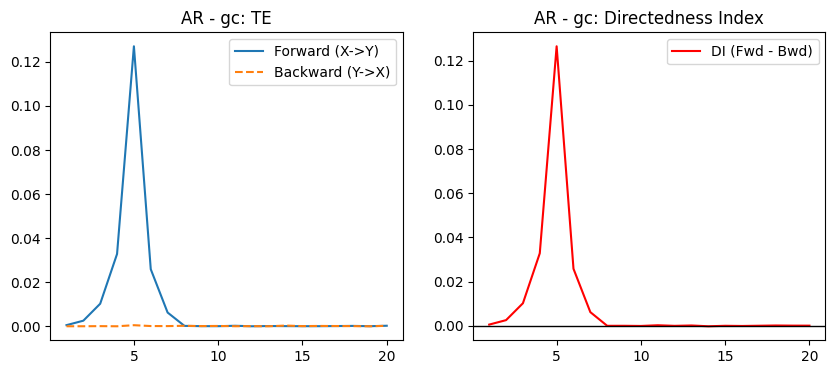

In [23]:
print(f"Running Symmetry Test for AR")
    
    # We will focus on one or two methods for clarity in the DI plot
for mth in ['binning', 'gauss', 'gc']: 
        m = optimal_params['m']
        # Forcing m=1 only for binning to avoid curse of dimensionality
        m_eff = 1 if mth == 'binning' else m
        tau = optimal_params['tau']

        # 1. Forward Direction (X -> Y)
        if mth == 'binning':
            te_fwd = [nl.transfer_entropy_withMI(x, y, method=mth, lag=l, m=m_eff, tau=tau, bins=bins_to_test) for l in lags]
            te_bwd = [nl.transfer_entropy_withMI(y, x, method=mth, lag=l, m=m_eff, tau=tau, bins=bins_to_test) for l in lags]
        else:
            te_fwd = [nl.transfer_entropy_withMI(x, y, method=mth, lag=l, m=m_eff, tau=tau) for l in lags]
            te_bwd = [nl.transfer_entropy_withMI(y, x, method=mth, lag=l, m=m_eff, tau=tau) for l in lags]
        
        # Calculate Directedness Index
        di = np.array(te_fwd) - np.array(te_bwd)
        
        # Plotting
        plt.figure(figsize=(10, 4))
        plt.subplot(1, 2, 1)
        plt.plot(lags, te_fwd, label='Forward (X->Y)')
        plt.plot(lags, te_bwd, label='Backward (Y->X)', linestyle='--')
        plt.title(f"AR - {mth}: TE")
        plt.legend()
        
        plt.subplot(1, 2, 2)
        plt.plot(lags, di, color='red', label='DI (Fwd - Bwd)')
        plt.axhline(0, color='black', lw=1)
        plt.title(f"AR - {mth}: Directedness Index")
        plt.legend()
        plt.show()

For the AR Model, we actually have a mathematical ground truth! Since it is a linear Gaussian system, the TE is analytically related to the log-ratio of the conditional variances. If the only thing $Y$ can't explain about its own future is the noise $\epsilon$ and the influence of $X$, then:$$TE_{True} \approx \frac{1}{2} \log_2 \left( 1 + \frac{\text{Variance contributed by } X}{\sigma_{noise}^2} \right)$$


### Stress Test - Noise Robustness ($\sigma$ Sweep)
We evaluate the sensitivity of our estimators by increasing the standard deviation of the additive process noise ($\sigma$). As $\sigma$ increases, the "information signal" from $X$ becomes a smaller fraction of the total variance of $Y$.
The "Indistinguishability" Criterion
To determine when a peak disappears, we compare the True TE against a Shuffled Baseline (Null Hypothesis).
Null Hypothesis: We shuffle the source signal $X$ to break the temporal link with $Y$ and compute "Surrogate TE."Indistinguishable Point: When the True TE falls within the error bars of the Shuffled TE, the estimator has failed.

Implementation Goals
Regenerate signals with $\sigma \in [0.01, 0.05, 0.1, 0.2, 0.5, 1.0]$. Calculate TE at the ground truth lag. Calculate "Shuffled TE" to provide a noise floor.

--- Sigma Noise Sweep ---


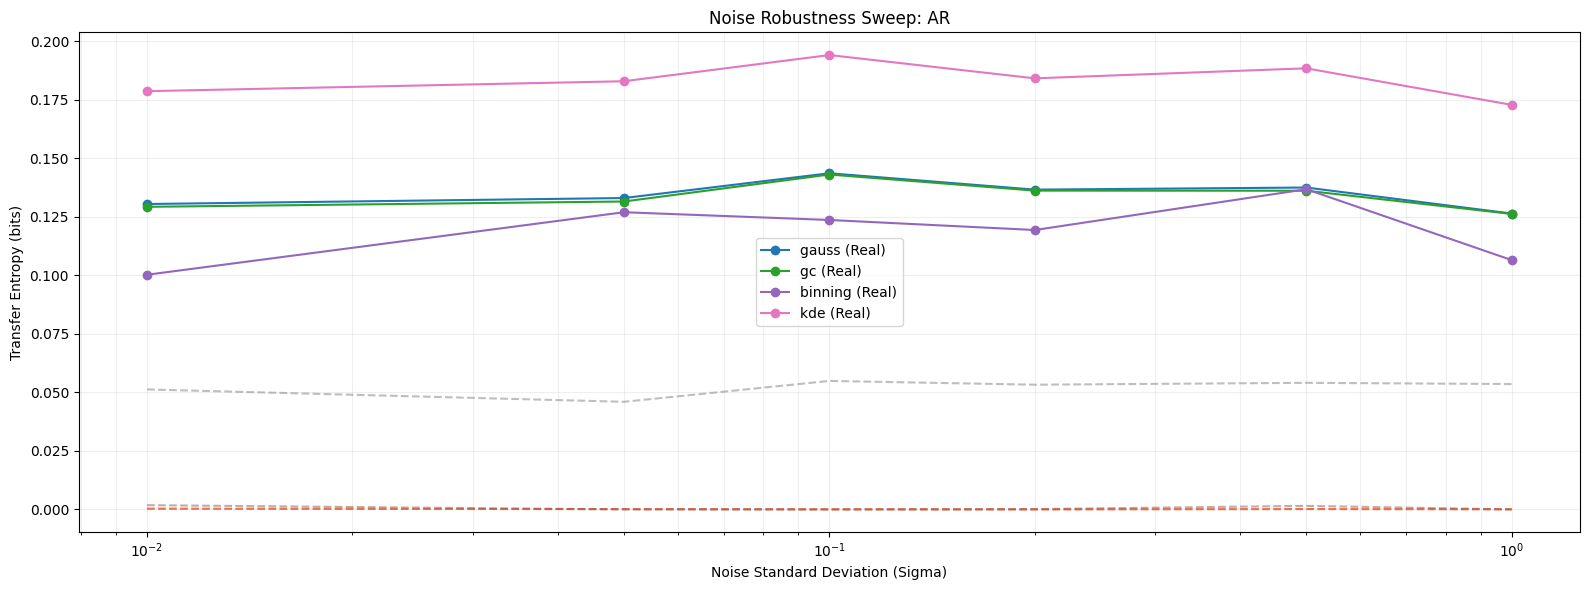

In [28]:
# 1. Setup
N = 5000
sigmas = [0.01, 0.05, 0.1, 0.2, 0.5, 1.0]
methods = ['gauss', 'gc', 'binning', 'kde']
bins_to_test = np.arange(5, 30)
results = []

print("--- Sigma Noise Sweep ---")


true_lag = 5 
#m_opt = optimal_params['m']
#tau_opt = optimal_params['tau']
m_opt=1
tau_opt=1
    
for s in sigmas:
        # REGENERATE the signal with specific sigma
        x, y = nl.generate_ar_coupled(N, lag=true_lag, sigma=s)
        #    
        # Create a shuffled version of X for the "Ground Truth Noise Floor"
        x_shuffled = np.random.permutation(x)
        
        for mth in methods:
            m_eff = 1 if mth == 'binning' else m_opt
            
            # Compute real TE
            if mth=="binning": te_real = nl.transfer_entropy_withMI(x, y, method=mth, lag=true_lag, 
                                                m=m_eff, tau=tau_opt, bins=bins_to_test)
            else: te_real = nl.transfer_entropy_withMI(x, y, method=mth, lag=true_lag, 
                                                m=m_eff, tau=tau_opt)
            
            # Compute Shuffled TE (The baseline)
            if mth=="binning": te_null = nl.transfer_entropy_withMI(x_shuffled, y, method=mth, lag=true_lag, 
                                                m=m_eff, tau=tau_opt, bins=bins_to_test)
            else: te_null = nl.transfer_entropy_withMI(x_shuffled, y, method=mth, lag=true_lag, 
                                                m=m_eff, tau=tau_opt)
            results.append({
                'Dataset': 'AR',
                'Method': mth,
                'Sigma': s,
                'TE_Real': te_real,
                'TE_Null': te_null
            })

df_noise = pd.DataFrame(results)

# 2. Plotting
fig, axes = plt.subplots(1, 1, figsize=(16, 6))


for mth in methods:
        subset = df_noise[(df_noise['Dataset'] == 'AR') & (df_noise['Method'] == mth)]
        plt.plot(subset['Sigma'], subset['TE_Real'], marker='o', label=f"{mth} (Real)")
        # Plot the noise floor for that method using same color but dotted
        plt.plot(subset['Sigma'], subset['TE_Null'], linestyle='--', alpha=0.5)
    
plt.title(f"Noise Robustness Sweep: AR")
plt.xlabel("Noise Standard Deviation (Sigma)")
plt.ylabel("Transfer Entropy (bits)")
plt.xscale('log') # Log scale helps see the drop-off
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.2)

plt.tight_layout()
plt.show()

# ideas 

Assunzione,Test suggerito,Perché farlo?

Stazionarietà,Augmented Dickey-Fuller (ADF) Test,Per essere sicuro che il segnale non abbia trend o derive che invalidano la stima della densità di probabilità.

Linearità,Confronto TE vs Granger,"Calcola la TE con method='gauss' (lineare) e con method='kde' (non lineare). Se i risultati sono molto diversi, hai la prova che nel tuo segnale neurale c'è dinamica non lineare."

Ordine Markoviano,AIC/BIC o FNN,Per giustificare la scelta dell'embedding dimension m. Dimostri che non hai scelto m=1 a caso.

Significatività,Surrogati (Shuffling),Per distinguere la TE reale dal bias statistico dovuto alla lunghezza finita del segnale.


Se accade che...,La conclusione scientifica è...

TE (Gauss) ≈ TE (KDE),Il legame tra i neuroni è prevalentemente lineare. La semplicità vince.

TE (KDE) ≫ TE (Gauss),Esistono interazioni non lineari complesse (es. accoppiamento di fase) che un modello lineare non vede.

TE (Binning) è molto instabile,"Il segnale è troppo rumoroso o hai scelto pochi bin. Il binning soffre il ""bias di discretizzazione""."

TE (Copula) è la più robusta,"Le distribuzioni dei segnali non sono gaussiane (hanno code lunghe), ma la struttura di dipendenza è chiara."

A. Grafico di Robustezza al RumoreGenera un segnale AR con un lag noto. Aggiungi livelli crescenti di rumore bianco e calcola la TE con tutti i metodi.Cosa osservare: Quale metodo "crolla" per primo? Solitamente il binning è il più sensibile al rumore, mentre la Gaussian Copula è spesso la più resiliente.

B. Analisi del Tempo di CalcoloSe hai segnali molto lunghi, riporta il tempo di esecuzione.KDE: Molto preciso ma lento ($O(N^2)$).Binning/Gauss: Velocissimi.Conclusione: "Il KDE è preferibile per segmenti brevi e analisi di precisione, mentre il Binning è adatto per screening veloci su grandi dataset."

## 📋 To-Do List

#### **Fase 1: Generazione e Pre-analisi**
* [OK] **Creazione Ground Truth:** Genera i segnali AR (lineare) e Oscillatori Accoppiati (non-lineare).
* [OK] **Test di Stazionarietà (ADF):** Verifica che i segnali siano stabili.
* [OK] **Ottimizzazione Parametri (su dati puliti e lunghi):**
    * Trova l'**Embedding Delay ($\tau$)** con il *First Minimum of MI*.
    * Trova l'**Embedding Dimension ($m$)** con il *False Nearest Neighbors (FNN)*.

#### **Fase 2: Benchmark e Lag Scanning (L'Ideale)**
* [OK] **Lag Scanning:** Esegui una scansione del lag sorgente (1-20) su dati con alto SNR e molti campioni.
* [OK] **Confronto Metodi:** Calcola la TE con **KDE, Binning, Gaussian, Gaussian Copula** per identificare il picco di informazione.


#### **Fase 3: Stress Test - Robustezza al Rumore**
* [ ] **Noise Sweep:** Fissa $N$ (es. 5000) e varia il rumore (SNR da 30dB a 0dB).
* [ ] **Analisi Errore:** Per ogni metodo, osserva a quale livello di rumore il picco di TE scompare o diventa indistinguibile dal rumore di fondo.

#### **Fase 4: Stress Test - Lunghezza del Segnale ($N$)**
* [ ] **Sample Sweep:** Fissa il rumore (basso) e varia il numero di campioni $N$ (es. 500, 1000, 2000, 5000, 10000).
* [ ] **Bias Check:** Osserva come il valore della TE "gonfia" artificialmente quando $N$ è piccolo (bias statistico).


#### **Fase 5: Validazione Statistica**
* [ ] **Permutation Test:** Applica lo shuffling della sorgente per definire la soglia di confidenza (P-value) per i risultati ottenuti nelle fasi precedenti.

#### **Fase 6: Sintesi Comparativa**
* [ ] **Report Finale:** Crea grafici che mostrano l'accuratezza (errore rispetto al lag reale) in funzione del rumore e di $N$ per tutti e 4 i metodi.

---

### 📅 Tabella di Marcia

| Fase | Attività Principale | Focus Tecnico | Output Atteso |
| :--- | :--- | :--- | :--- |
| **Fase 1: Setup** | Generazione & Diagnostica | ADF, FNN, First Min MI | Parametri $m, \tau$ e stazionarietà confermata. |
| **Fase 2: Core** | Lag Scanning & Metodi | Confronto KDE, Binning, GC, Gauss | Grafico TE vs Lag (identificazione del picco). |
| **Fase 3: Rumore** | **Stress Test: Rumore** | Sweep SNR (0-30 dB) | Curve di decadimento della TE per ogni metodo. |
| **Fase 4: Dati** | **Stress Test: Campioni ($N$)** | Sweep $N$ (500-10.000) | Analisi del bias e stabilità della stima. |
| **Fase 5: Stat** | Permutation Test | Shuffling & Significatività | Barre di errore e soglie di confidenza (P < 0.05). |
| **Fase 6: Final** | Analisi Risultati | Confronto prestazioni totali | Tabella finale: "Qual è il metodo migliore?". |

---

### 💡 Un consiglio strategico per il tuo report
Quando confronterai i metodi sotto stress, probabilmente noterai che:
1.  **Gaussian Copula** sarà il più veloce e robusto al rumore.
2.  **KDE** sarà il più preciso per gli oscillatori ma "esploderà" in termini di tempo di calcolo se $N$ è troppo grande o fallirà se $N$ è troppo piccolo.
3.  **Binning** mostrerà un alto bias positivo quando $N$ è piccolo.

Presentare questi fallimenti è **più importante** che presentare solo i successi, perché dimostra che hai capito i limiti fisici dell'Information Theory.

Quale di questi due stress test ti preoccupa di più in termini di potenza di calcolo del tuo PC? (Se il KDE è lento, lo sweep su $N$ potrebbe richiedere ore).